In [4]:
import pandas as pd

xls = pd.ExcelFile(r"C:\Users\USER\Downloads\WUP2025-F02-Degree-of-Urbanization_percPop_by_category.xlsx")
print(xls.sheet_names)


['info', 'Rural', 'Towns', 'Cities', 'Cities and Towns', 'NOTES']


In [5]:
import pandas as pd

df_cities = pd.read_excel(
    r"C:\Users\USER\Downloads\WUP2025-F02-Degree-of-Urbanization_percPop_by_category.xlsx",
    sheet_name="Cities",
    engine="openpyxl"
)

df_cities.head()

,Index,Location,Notes,LocID,ISO3_Code,ISO2_Code,SDMX_Code,LocType,LocTypeName,ParentID,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,1,WORLD,a,900,NaN,NaN,1.0,1,World,0,...,47.167,47.302,47.436,47.568,47.699,47.831,47.961,48.090,48.218,48.345
1,2,Sustainable Development Goal (SDG) regions,b,1828,NaN,NaN,NaN,25,Label/Separator,900,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Sub-Saharan Africa,NaN,1834,NaN,NaN,202.0,12,SDG region,1828,...,40.740,40.934,41.121,41.301,41.475,41.695,41.908,42.113,42.311,42.504
3,4,Northern Africa and Western Asia,NaN,1833,NaN,NaN,747.0,12,SDG region,1828,...,62.824,63.072,63.315,63.552,63.782,63.990,64.194,64.393,64.588,64.779
4,5,Central and Southern Asia,NaN,1831,NaN,NaN,62.0,12,SDG region,1828,...,46.348,46.528,46.706,46.883,47.057,47.232,47.406,47.578,47.748,47.916


In [7]:
df_cities["Location"].unique()[:20]

array(['WORLD', 'Sustainable Development Goal (SDG) regions',
       'Sub-Saharan Africa', 'Northern Africa and Western Asia',
       'Central and Southern Asia', 'Eastern and South-Eastern Asia',
       'Eastern and South-Eastern Asia, and Oceania (excluding Australia and New Zealand)',
       'Latin America and the Caribbean',
       'Oceania (excluding Australia and New Zealand)',
       'Australia/New Zealand', 'Europe and Northern America',
       'Europe, Northern America, Australia and New Zealand',
       'UN development groups', 'More developed regions',
       'Less developed regions', 'Least developed countries',
       'Less developed regions, excluding least developed countries',
       'Less developed regions, excluding China',
       'Land-locked Developing Countries (LLDC)', 'LLDC: Africa'],
      dtype=object)

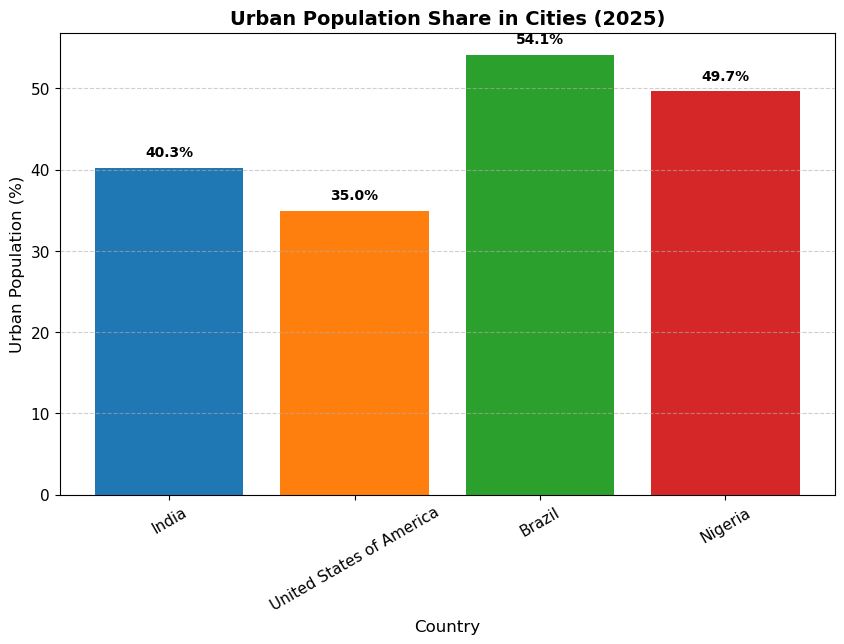

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
df_cities = pd.read_excel(
    r"C:\Users\USER\Downloads\WUP2025-F02-Degree-of-Urbanization_percPop_by_category.xlsx",
    sheet_name="Cities",
    engine="openpyxl"
)
countries = ["India", "China, mainland", "United States of America", "Brazil", "Nigeria"]
year = "2025"
data = []
labels = []
for country in countries:
    row = df_cities[df_cities["Location"]==country]
    if not row.empty:
        labels.append(country)
        data.append(row[year].values[0])
        
plt.figure(figsize=(10,6))
bars = plt.bar(labels, data, color=["#1f77b4","#ff7f0e","#2ca02c","#d62728","#9467bd"])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,
             f"{height:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.title(f"Urban Population Share in Cities ({year})", fontsize=14, fontweight="bold")
plt.xlabel("Country", fontsize=12)
plt.ylabel("Urban Population (%)", fontsize=12)
plt.xticks(rotation=30, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()
